# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [1]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [2]:
# Inspect the shapes of the datasets
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [3]:
# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical

print(f'Before one-hot encoding: {y_train[0]}')
y_train_ohe = to_categorical(y_train, num_classes=10)
y_test_ohe = to_categorical(y_test, num_classes=10)
print(f'After one-hot encoding: {y_train_ohe[0]}')

Before one-hot encoding: 9
After one-hot encoding: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


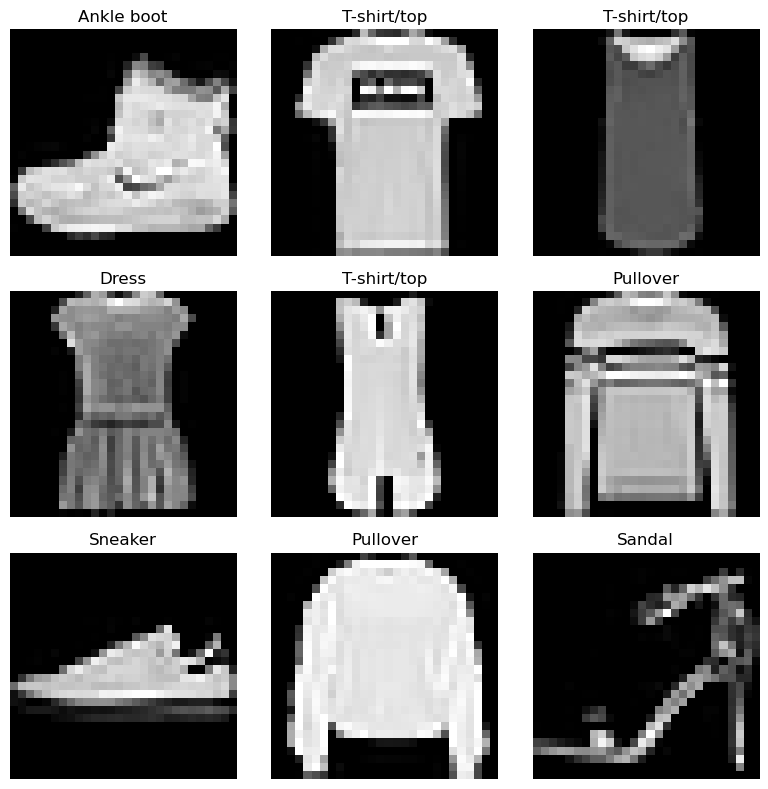

In [4]:
import matplotlib.pyplot as plt
# Verify the data looks as expected
plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**The data looks similar to class names. The quality of the images are a little low. That is to be expected when the images are 28x28 pixels**

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [12]:
from keras.models import Sequential
from keras.layers import Dense, Flatten

# Create a simple linear regression model
model = Sequential()
# You can use `model.add(<layer>)` to add layers to the model
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(64, activation=None))      
model.add(Dense(10, activation='softmax'))
# Compile the model using `model.compile()`
model.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy'] 
)
# Train the model with `model.fit()`
history = model.fit(
    X_train,
    y_train_ohe,
    epochs=10,
    batch_size=32,
    validation_split=0.2  
)

Epoch 1/10
1500/1500 [==============================] - 6s 4ms/step - loss: 0.7417 - accuracy: 0.7536 - val_loss: 0.5694 - val_accuracy: 0.8044
Epoch 2/10
1500/1500 [==============================] - 6s 4ms/step - loss: 0.5300 - accuracy: 0.8211 - val_loss: 0.5203 - val_accuracy: 0.8111
Epoch 3/10
1500/1500 [==============================] - 6s 4ms/step - loss: 0.4877 - accuracy: 0.8328 - val_loss: 0.4982 - val_accuracy: 0.8190
Epoch 4/10
1500/1500 [==============================] - 5s 3ms/step - loss: 0.4653 - accuracy: 0.8389 - val_loss: 0.4592 - val_accuracy: 0.8385
Epoch 5/10
1500/1500 [==============================] - 6s 4ms/step - loss: 0.4521 - accuracy: 0.8438 - val_loss: 0.4570 - val_accuracy: 0.8401
Epoch 6/10
1500/1500 [==============================] - 5s 4ms/step - loss: 0.4419 - accuracy: 0.8479 - val_loss: 0.4548 - val_accuracy: 0.8410
Epoch 7/10
1500/1500 [==============================] - 5s 3ms/step - loss: 0.4347 - accuracy: 0.8501 - val_loss: 0.4443 - val_accuracy:

In [18]:
# Evaluate the model with `model.evaluate()`
loss, accuracy = model.evaluate(X_test, y_test_ohe)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

313/313 [==============================] - 1s 3ms/step - loss: 0.4701 - accuracy: 0.8351
Loss:     0.47
Accuracy: 83.51%


Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

**The performance of the baseline model is not bad given there is no activation function applied. Although there was no activation i think the model is still sucessful because there is a flatten step that evaluates the image as a 1D array.**

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [ ]:
from keras.layers import Conv2D, MaxPooling2D, Dropout

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model1 = Sequential()
model1.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))  
model1.add(MaxPooling2D(pool_size=(2, 2)))  
model1.add(Flatten())                      
model1.add(Dense(64, activation='relu'))  
model1.add(Dense(10, activation='softmax'))  

model1.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])
# Train the model
history1 = model1.fit(X_train, y_train_ohe,
                      epochs=10,
                      batch_size=32,
                      validation_split=0.2)
# Evaluate the model
test_loss, test_accuracy = model1.evaluate(X_test, y_test_ohe)
print(f"Test Accuracy: {test_accuracy:.4f}")

Epoch 1/10
1500/1500 [==============================] - 33s 22ms/step - loss: 0.4329 - accuracy: 0.8474 - val_loss: 0.3174 - val_accuracy: 0.8878
Epoch 2/10
1500/1500 [==============================] - 26s 17ms/step - loss: 0.2909 - accuracy: 0.8967 - val_loss: 0.3126 - val_accuracy: 0.8900
Epoch 3/10
1500/1500 [==============================] - 25s 17ms/step - loss: 0.2486 - accuracy: 0.9105 - val_loss: 0.2938 - val_accuracy: 0.8963
Epoch 4/10
1500/1500 [==============================] - 27s 18ms/step - loss: 0.2166 - accuracy: 0.9209 - val_loss: 0.2661 - val_accuracy: 0.9063
Epoch 5/10
1500/1500 [==============================] - 28s 18ms/step - loss: 0.1941 - accuracy: 0.9284 - val_loss: 0.2687 - val_accuracy: 0.9045
Epoch 6/10
1500/1500 [==============================] - 38s 26ms/step - loss: 0.1714 - accuracy: 0.9372 - val_loss: 0.2513 - val_accuracy: 0.9139
Epoch 7/10
1500/1500 [==============================] - 38s 25ms/step - loss: 0.1532 - accuracy: 0.9437 - val_loss: 0.2599 -

Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

**The CNN model performed better than the baseline model. There was a change from 83% to 90% improvedment in test accuracy. I beleive this improvedment is a result of the CNN model able to detect non-linear relationships which helps with the image detection. This helps with detection of edges and shapes. **

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [ ]:
#Test hyperparameters
from keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

# Define hyperparameter and regularization options
filter_options = [32, 64, 128]
use_dropout_options = [False, True]

# Store results
results = []

# Loop over all combinations
for filters in filter_options:
    for use_dropout in use_dropout_options:
        print(f"Training with {filters} filters, Dropout: {use_dropout}")

        # Define and build model
        model2 = Sequential()
        model2.add(Conv2D(filters, (3, 3), activation='relu', input_shape=(28, 28, 1)))
        model2.add(MaxPooling2D(pool_size=(2, 2)))

        if use_dropout:
            model2.add(Dropout(0.25)) 
        
        model2.add(Flatten())
        model2.add(Dense(64, activation='relu'))

        if use_dropout:
            model2.add(Dropout(0.5))  

        model2.add(Dense(10, activation='softmax'))

        # Compile and train
        model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        model2.fit(X_train, y_train_ohe, epochs=5, batch_size=32, verbose=0)

        # Evaluate and store results
        test_loss, test_acc = model2.evaluate(X_test, y_test_ohe, verbose=0)
        print(f"Test Accuracy: {test_acc:.4f}")

        results.append({
            'filters': filters,
            'use_dropout': use_dropout,
            'test_accuracy': test_acc
        })

Training with 32 filters, Dropout: False
Test Accuracy: 0.9030
Training with 32 filters, Dropout: True
Test Accuracy: 0.8939
Training with 64 filters, Dropout: False
Test Accuracy: 0.9106
Training with 64 filters, Dropout: True
Test Accuracy: 0.8988
Training with 128 filters, Dropout: False
Test Accuracy: 0.9087
Training with 128 filters, Dropout: True
Test Accuracy: 0.9025


In [ ]:
import pandas as pd
# Find best hyperparameter to use
# Convert results to DataFrame
df_results = pd.DataFrame(results)

# Find the best configuration (highest test accuracy)
best_result = df_results.loc[df_results['test_accuracy'].idxmax()]

print("\nBest hyperparameter configuration:")
print(f"Filters: {best_result['filters']}")
print(f"Use Dropout: {best_result['use_dropout']}")
print(f"Test Accuracy: {best_result['test_accuracy']:.4f}")


Best hyperparameter configuration:
Filters: 64
Use Dropout: False
Test Accuracy: 0.9106


In [51]:
# B. Test presence or absence of regularization
def create_model(use_dropout=False):
    model3 = Sequential()
    model3.add(Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)))
    model3.add(MaxPooling2D(pool_size=(2, 2)))
    if use_dropout:
        model3.add(Dropout(0.25))  
    model3.add(Flatten())
    model3.add(Dense(64, activation='relu'))
    if use_dropout:
        model3.add(Dropout(0.5))   
    model3.add(Dense(10, activation='softmax'))
    
    model3.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
    return model3

In [52]:
results2 = {}

# Without Dropout
model_no_dropout = create_model(use_dropout=False)
model_no_dropout.fit(X_train, y_train_ohe, epochs=5, batch_size=32, verbose=0)
loss, acc = model_no_dropout.evaluate(X_test, y_test_ohe, verbose=0)
results2['No Dropout'] = acc

# With Dropout
model_with_dropout = create_model(use_dropout=True)
model_with_dropout.fit(X_train, y_train_ohe, epochs=5, batch_size=32, verbose=0)
loss, acc = model_with_dropout.evaluate(X_test, y_test_ohe, verbose=0)
results2['With Dropout'] = acc

In [53]:
for condition, accuracy in results2.items():
    print(f"{condition}: Test Accuracy = {accuracy:.4f}")

No Dropout: Test Accuracy = 0.9119
With Dropout: Test Accuracy = 0.8965


Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

**The best hyperpareter adjutments was Training with 64 filters, Dropout: False. This resulted in a Test Accuracy Score: 0.9106**

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [54]:
final_model = Sequential()
final_model.add(Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)))
final_model.add(MaxPooling2D(pool_size=(2, 2)))
final_model.add(Flatten())
final_model.add(Dense(64, activation='relu'))
final_model.add(Dense(10, activation='softmax'))

In [55]:
# Compile model
final_model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Train model
final_model.fit(X_train, y_train_ohe, epochs=10, batch_size=32, verbose=1)

Epoch 1/10
1875/1875 [==============================] - 54s 28ms/step - loss: 0.4134 - accuracy: 0.8547
Epoch 2/10
1875/1875 [==============================] - 51s 27ms/step - loss: 0.2783 - accuracy: 0.8995
Epoch 3/10
1875/1875 [==============================] - 52s 27ms/step - loss: 0.2379 - accuracy: 0.9133
Epoch 4/10
1875/1875 [==============================] - 53s 28ms/step - loss: 0.2083 - accuracy: 0.9233
Epoch 5/10
1875/1875 [==============================] - 54s 29ms/step - loss: 0.1826 - accuracy: 0.9334
Epoch 6/10
1875/1875 [==============================] - 56s 30ms/step - loss: 0.1613 - accuracy: 0.9401
Epoch 7/10
1875/1875 [==============================] - 55s 29ms/step - loss: 0.1416 - accuracy: 0.9468
Epoch 8/10
1875/1875 [==============================] - 54s 29ms/step - loss: 0.1241 - accuracy: 0.9536
Epoch 9/10
1875/1875 [==============================] - 55s 29ms/step - loss: 0.1094 - accuracy: 0.9598
Epoch 10/10
1875/1875 [==============================] - 55s 29m

In [56]:
test_loss, test_accuracy = final_model.evaluate(X_test, y_test_ohe, verbose=0)
print(f"Final Test Accuracy: {test_accuracy:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

Final Test Accuracy: 0.9174
Final Test Loss: 0.2885


313/313 [==============================] - 2s 7ms/step
              precision    recall  f1-score   support

 T-shirt/top       0.87      0.87      0.87      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.86      0.88      0.87      1000
       Dress       0.92      0.91      0.92      1000
        Coat       0.82      0.90      0.86      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.81      0.73      0.77      1000
     Sneaker       0.96      0.98      0.97      1000
         Bag       0.97      0.98      0.98      1000
  Ankle boot       0.97      0.96      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



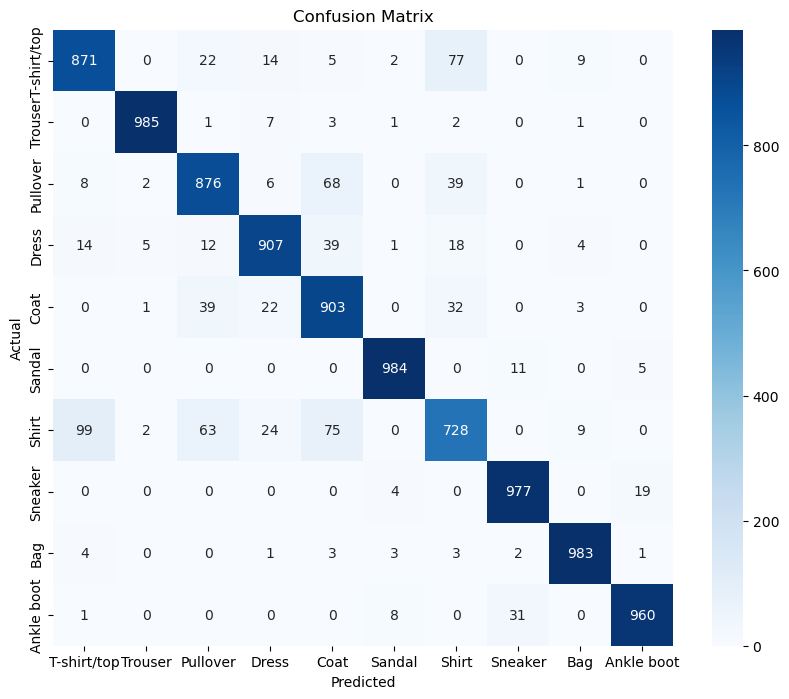

In [57]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predict class labels
y_pred_probs = final_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_ohe, axis=1)

# Classification report
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

**The final model with optimized hyperparameters does slightly better than the CNN model. There is an increase in test score from 90% ot 91% which is not a big increase. The tuned hyperparameters made sure the model was not overfitting the data which helps find the small increase in test score accuracy.  **

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 06/07/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-6-ml-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.